In [24]:
!pip install scikit-learn==1.5.2
!pip install scikeras==0.13.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 55.7 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.model_selection import RandomizedSearchCV

from scikeras.wrappers import KerasClassifier

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
tf.random.set_seed(42)

In [2]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)

print("Testing Images :", X_test.shape)
print("Testing Labels :", y_test.shape)

Training Images : (60000, 28, 28)
Training Labels : (60000,)
Testing Images : (10000, 28, 28)
Testing Labels : (10000,)


In [3]:
class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

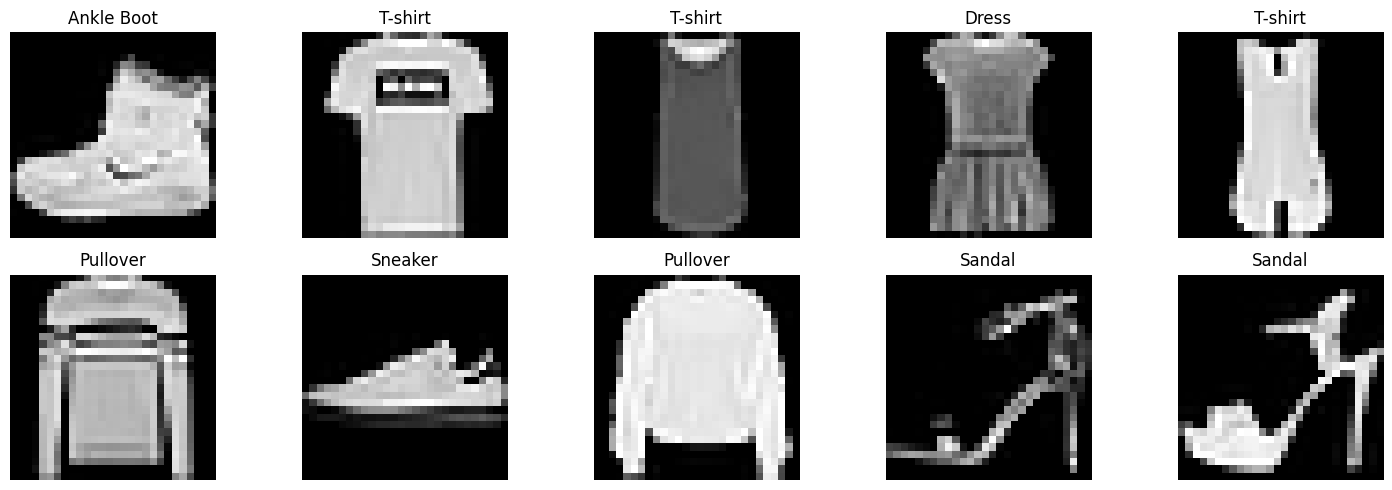

In [4]:
plt.figure(figsize=(15,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

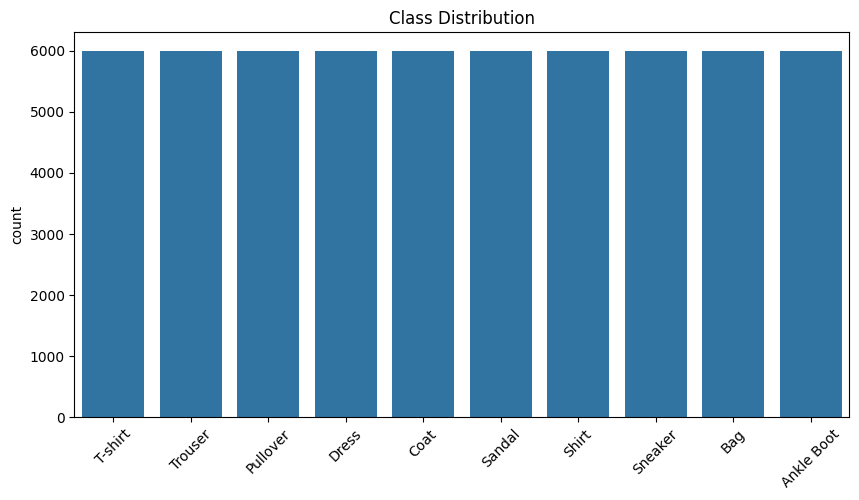

In [5]:
plt.figure(figsize=(10,5))

sns.countplot(x=y_train)

plt.xticks(range(10), class_names, rotation=45)
plt.title("Class Distribution")
plt.show()

In [6]:
print("Before Flattening")

print(X_train.shape)
print(X_test.shape)

X_train = X_train.reshape(-1,784)
X_test = X_test.reshape(-1,784)

print("\nAfter Flattening")

print(X_train.shape)
print(X_test.shape)

X_train = X_train.astype("float32")/255.0
X_test = X_test.astype("float32")/255.0

y_train_cat = to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10)

print("\nOne Hot Shape")

print(y_train_cat.shape)

Before Flattening
(60000, 28, 28)
(10000, 28, 28)

After Flattening
(60000, 784)
(10000, 784)

One Hot Shape
(60000, 10)


In [7]:
baseline_model = Sequential([

    Input(shape=(784,)),

    Dense(128,activation="relu"),

    Dense(64,activation="relu"),

    Dense(10,activation="softmax")

])

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
baseline_model.compile(

    optimizer="adam",

    loss="categorical_crossentropy",

    metrics=["accuracy"]

)

In [24]:
history = baseline_model.fit(

    X_train,
    y_train_cat,

    validation_split=0.2,

    epochs=20,

    batch_size=32,

    verbose=1

)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9385 - loss: 0.1616 - val_accuracy: 0.8858 - val_loss: 0.4050
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.9412 - loss: 0.1575 - val_accuracy: 0.8824 - val_loss: 0.4475
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9411 - loss: 0.1548 - val_accuracy: 0.8802 - val_loss: 0.4368
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9438 - loss: 0.1493 - val_accuracy: 0.8857 - val_loss: 0.4121
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9448 - loss: 0.1462 - val_accuracy: 0.8811 - val_loss: 0.4567
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9475 - loss: 0.1408 - val_accuracy: 0.8752 - val_loss: 0.4600
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9486 - loss: 0.1359 - val_accuracy: 0.8813 - val_loss: 0.4588
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9489 - loss: 0.1348 

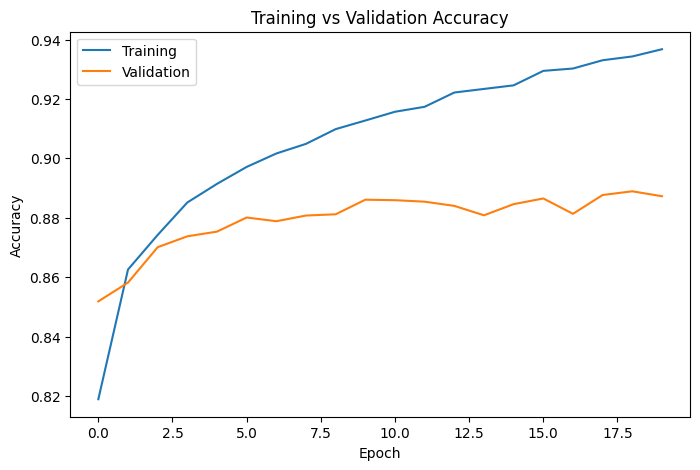

In [10]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"],label="Training")

plt.plot(history.history["val_accuracy"],label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.title("Training vs Validation Accuracy")

plt.show()

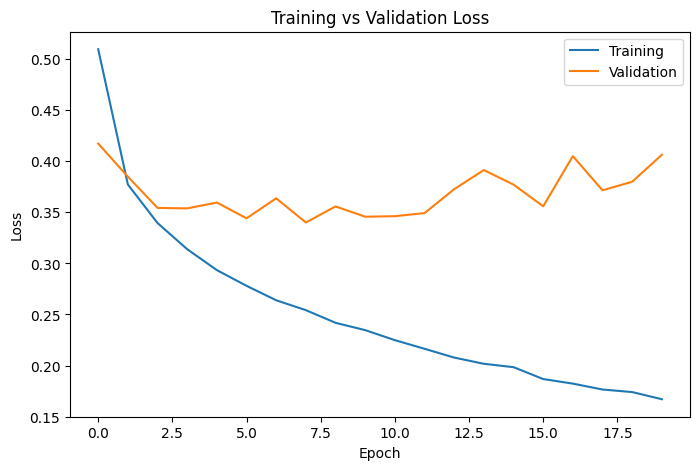

In [11]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"],label="Training")

plt.plot(history.history["val_loss"],label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.title("Training vs Validation Loss")

plt.show()

In [12]:
pred_prob = baseline_model.predict(X_test)

pred = np.argmax(pred_prob,axis=1)

accuracy = accuracy_score(y_test,pred)

precision = precision_score(y_test,pred,average="weighted")

recall = recall_score(y_test,pred,average="weighted")

f1 = f1_score(y_test,pred,average="weighted")

print("Accuracy :",accuracy)

print("Precision :",precision)

print("Recall :",recall)

print("F1 Score :",f1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy : 0.8774
Precision : 0.8772383554304386
Recall : 0.8774
F1 Score : 0.8763071830955578


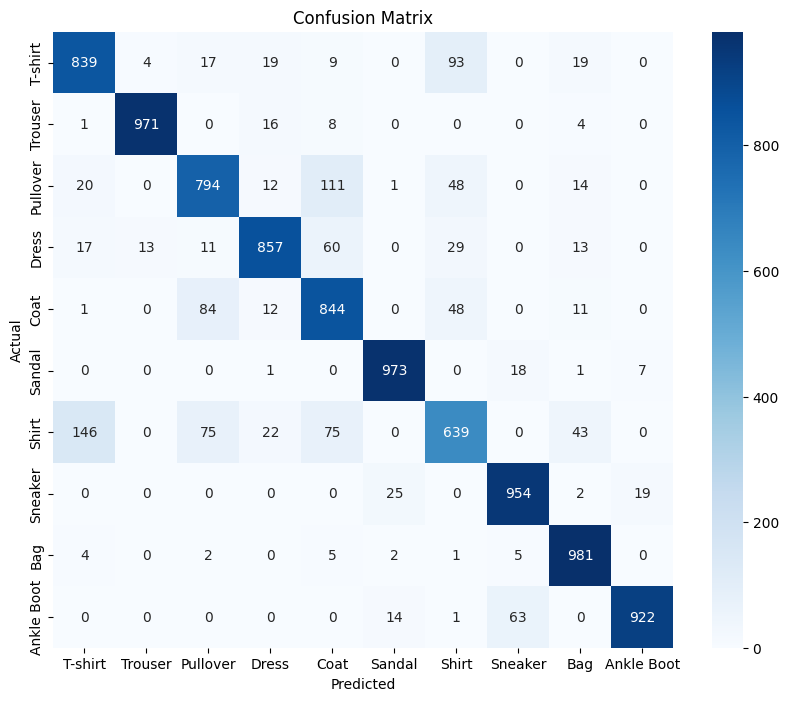

In [13]:
cm = confusion_matrix(y_test,pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [14]:
print(classification_report(
    y_test,
    pred,
    target_names=class_names
))

              precision    recall  f1-score   support

     T-shirt       0.82      0.84      0.83      1000
     Trouser       0.98      0.97      0.98      1000
    Pullover       0.81      0.79      0.80      1000
       Dress       0.91      0.86      0.88      1000
        Coat       0.76      0.84      0.80      1000
      Sandal       0.96      0.97      0.97      1000
       Shirt       0.74      0.64      0.69      1000
     Sneaker       0.92      0.95      0.94      1000
         Bag       0.90      0.98      0.94      1000
  Ankle Boot       0.97      0.92      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [15]:
def create_model(

        hidden_layers=2,

        neurons=128,

        learning_rate=0.001,

        optimizer="adam",

        activation="relu",

        dropout_rate=0.0

):

    model = Sequential()

    model.add(Input(shape=(784,)))

    for i in range(hidden_layers):

        model.add(Dense(neurons,activation=activation))

        if dropout_rate>0:

            model.add(Dropout(dropout_rate))

    model.add(Dense(10,activation="softmax"))

    if optimizer=="adam":

        opt=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        )

    elif optimizer=="sgd":

        opt=tf.keras.optimizers.SGD(
            learning_rate=learning_rate
        )

    else:

        opt=tf.keras.optimizers.RMSprop(
            learning_rate=learning_rate
        )

    model.compile(

        optimizer=opt,

        loss="categorical_crossentropy",

        metrics=["accuracy"]

    )

    return model

In [16]:
clf = KerasClassifier(

    model=create_model,

    verbose=0

)

In [17]:
param_grid = {

    "model__hidden_layers":[1,2,3],

    "model__neurons":[32,64,128,256],

    "model__learning_rate":[0.1,0.01,0.001],

    "model__optimizer":["adam","sgd","rmsprop"],

    "model__activation":["relu","tanh","sigmoid"],

    "model__dropout_rate":[0.0,0.2,0.5],

    "batch_size":[16,32,64,128],

    "epochs":[10,20,30]

}

In [18]:
random_search = RandomizedSearchCV(

    estimator=clf,

    param_distributions=param_grid,

    n_iter=20,

    cv=5,

    scoring="accuracy",

    verbose=2,

    random_state=42,

    n_jobs=-1

)

In [27]:
random_search.fit(

    X_train,

    y_train_cat

)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


KeyboardInterrupt: 

In [29]:
print("Best Parameters\n")

print(random_search.best_params_)

print()

print("Best Cross Validation Accuracy")

print(random_search.best_score_)

Best Parameters



AttributeError: 'RandomizedSearchCV' object has no attribute 'best_params_'

In [ ]:
results = pd.DataFrame(random_search.cv_results_)

results.head()

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(results["mean_test_score"])

plt.xlabel("Search Iteration")

plt.ylabel("CV Accuracy")

plt.title("Hyperparameter Search Results")

plt.show()

In [ ]:
best_model = random_search.best_estimator_

best_model.fit(

    X_train,

    y_train_cat

)

In [ ]:
pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test,pred)

precision = precision_score(
    y_test,
    pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    pred,
    average="weighted"
)

print("Optimized Accuracy :",accuracy)

print("Optimized Precision :",precision)

print("Optimized Recall :",recall)

print("Optimized F1 :",f1)

In [ ]:
cm = confusion_matrix(y_test,pred)

plt.figure(figsize=(10,8))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Greens",

    xticklabels=class_names,

    yticklabels=class_names

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Optimized Model Confusion Matrix")

plt.show()

In [ ]:
baseline_acc = history.history["val_accuracy"][-1]

optimized_acc = accuracy

plt.figure(figsize=(6,5))

plt.bar(

    ["Baseline","Optimized"],

    [baseline_acc,optimized_acc]

)

plt.ylabel("Accuracy")

plt.title("Baseline vs Optimized")

plt.show()

In [ ]:
comparison = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Baseline":[
        accuracy_score(y_test,np.argmax(baseline_model.predict(X_test),axis=1)),
        precision_score(y_test,np.argmax(baseline_model.predict(X_test),axis=1),average="weighted"),
        recall_score(y_test,np.argmax(baseline_model.predict(X_test),axis=1),average="weighted"),
        f1_score(y_test,np.argmax(baseline_model.predict(X_test),axis=1),average="weighted")
    ],

    "Optimized":[
        accuracy,
        precision,
        recall,
        f1
    ]

})

comparison